# Job Skill Set Analysis

This notebook performs exploratory data analysis on the Job Skill Set dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_theme(style="whitegrid")

In [2]:
data_path = "../data/raw/job_skill_set/all_job_post.csv"
df = pd.read_csv(data_path)
df.head()

,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (1167, 5)

Columns: ['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           1167 non-null   int64
 1   category         1167 non-null   str  
 2   job_title        1167 non-null   str  
 3   job_description  1167 non-null   str  
 4   job_skill_set    1167 non-null   str  
dtypes: int64(1), str(4)
memory usage: 45.7 KB


In [5]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

Duplicate Rows: 0


In [6]:
df.describe(include='all')

,job_id,category,job_title,job_description,job_skill_set
count,1.167000e+03,1167,1167,1167,1167
unique,NaN,5,723,1167,1167
top,NaN,INFORMATION-TECHNOLOGY,Business Development Manager,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
freq,NaN,240,53,1,1
mean,3.899002e+09,NaN,NaN,NaN,NaN
std,1.178123e+07,NaN,NaN,NaN,NaN
min,3.651735e+09,NaN,NaN,NaN,NaN
25%,3.895206e+09,NaN,NaN,NaN,NaN
50%,3.901983e+09,NaN,NaN,NaN,NaN
75%,3.904505e+09,NaN,NaN,NaN,NaN


In [7]:
print("Number of unique categories:", df['category'].nunique())
print("Number of unique job titles:", df['job_title'].nunique())

Number of unique categories: 5
Number of unique job titles: 723


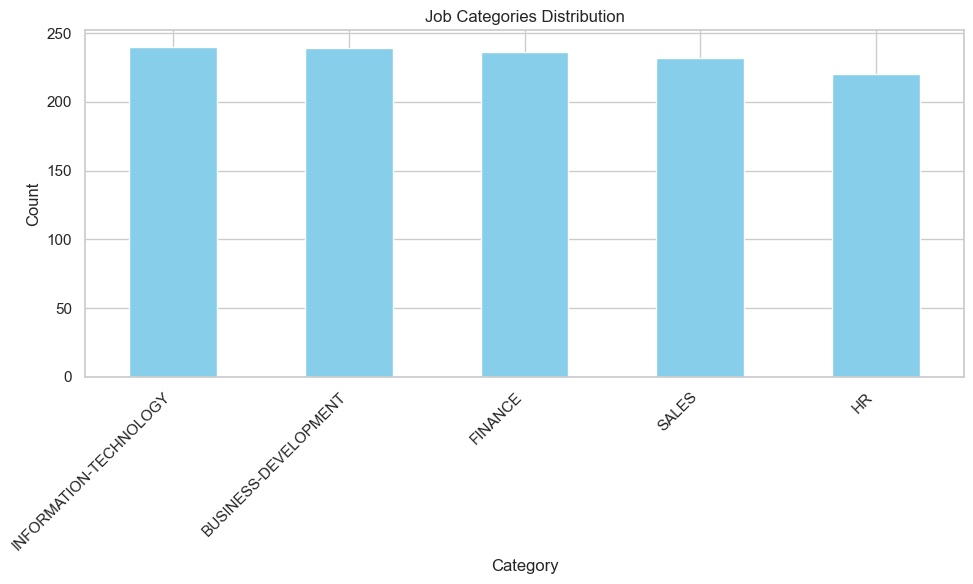

In [8]:
plt.figure(figsize=(10, 6))
df['category'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Job Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

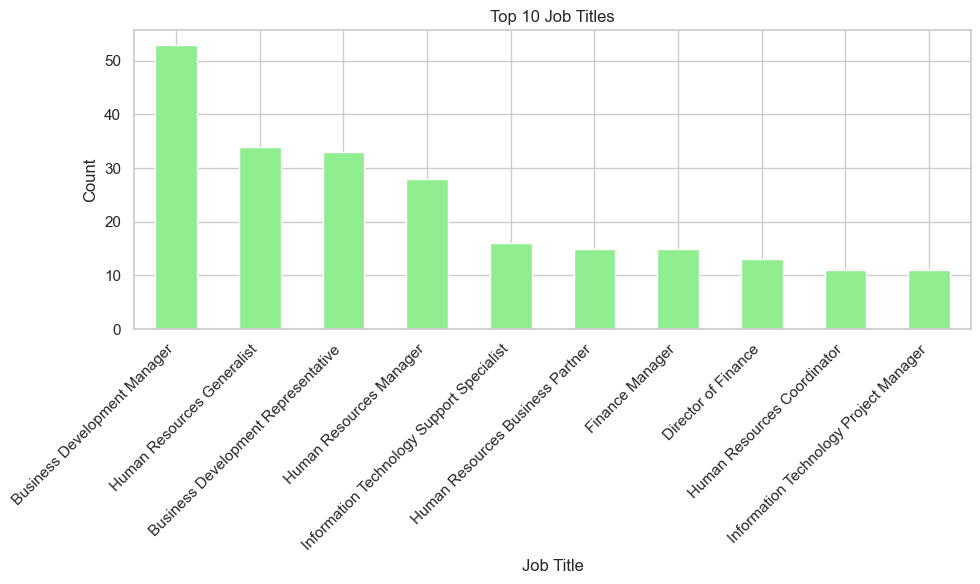

In [9]:
plt.figure(figsize=(10, 6))
df['job_title'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

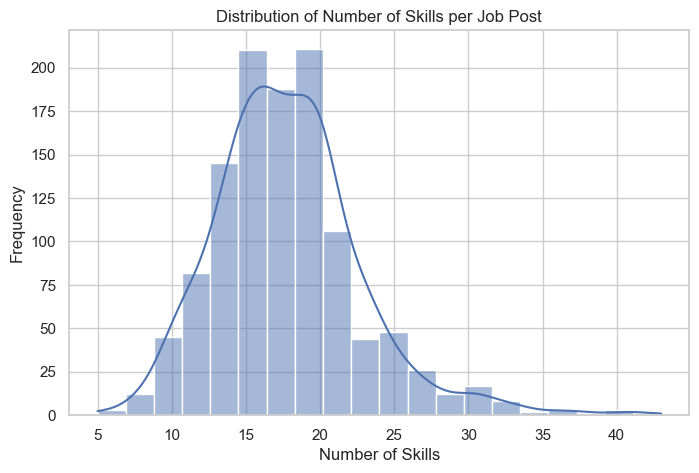

In [10]:
def extract_skills(skill_str):
    try:
        return ast.literal_eval(skill_str)
    except:
        return []

df['parsed_skills'] = df['job_skill_set'].apply(extract_skills)
df['num_skills'] = df['parsed_skills'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(df['num_skills'], bins=20, kde=True)
plt.title("Distribution of Number of Skills per Job Post")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")
plt.show()

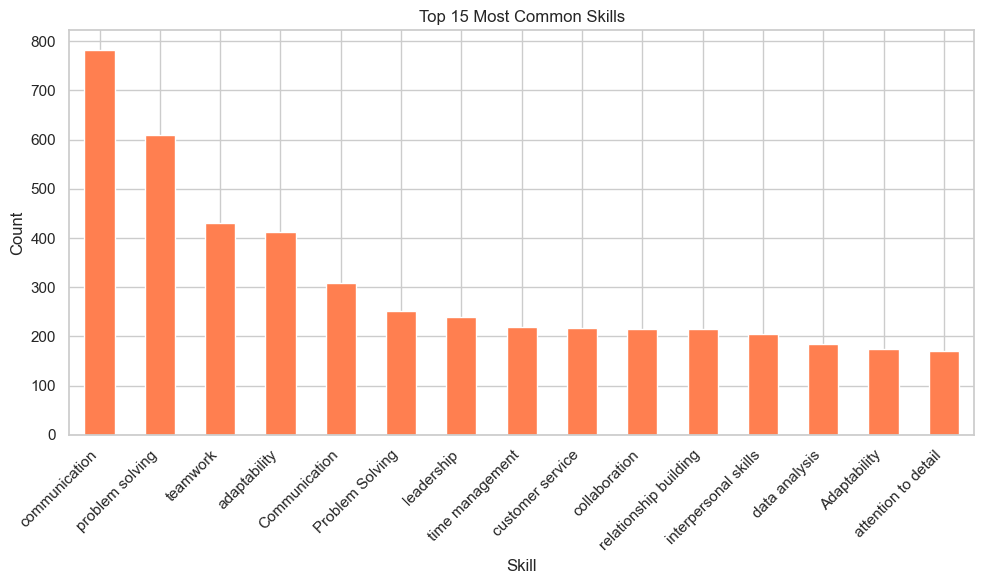

In [11]:
all_skills = [skill for skills_list in df['parsed_skills'] for skill in skills_list]
skill_counts = pd.Series(all_skills).value_counts()

plt.figure(figsize=(10, 6))
skill_counts.head(15).plot(kind='bar', color='coral')
plt.title("Top 15 Most Common Skills")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusion

- The dataset contains 1167 job postings across various categories.
- There are 0 missing values and 0 duplicate rows.
- The most common job categories are well distributed, but certain titles appear much more frequently.
- The `job_skill_set` column requires parsing from a stringified list to a native Python list to extract skills.
- The number of skills per job post varies, with most jobs requiring a moderate number of specific skills.